In [8]:
# Lab: Image Stitching and Panorama Creation
# Objective: Build panorama from overlapping photos using classical CV methods
# Tools: Python + OpenCV
#
# Features:
#   • Manual step-by-step stitching (ORB + Homography + simple blending)
#   • OpenCV Stitcher class (PANORAMA & SCANS modes)
#   • Exposure compensation & multi-band blending (advanced)
#   • Visualization & comparison
#
# Requirements:
# !pip install opencv-python opencv-contrib-python numpy matplotlib kagglehub

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple
import os
from pathlib import Path

In [11]:
!pip install kagglehub

  Using cached kagglehub-1.0.0-py3-none-any.whl.metadata (40 kB)
  Using cached kagglesdk-0.1.16-py3-none-any.whl.metadata (13 kB)
Using cached kagglehub-1.0.0-py3-none-any.whl (70 kB)
Using cached kagglesdk-0.1.16-py3-none-any.whl (160 kB)

   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   -------------------- ------------------- 1/2 [kagglehub]
   ---------------------------------------- 2/2 [kagglehub]



### Kaggle Dataset

In [2]:
import kagglehub

path = kagglehub.dataset_download("yaseenksk/dataset-panorama")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\dell\.cache\kagglehub\datasets\yaseenksk\dataset-panorama\versions\1


In [3]:
print("Dataset folder:", path)
print("Files inside:", os.listdir(path))

Dataset folder: C:\Users\dell\.cache\kagglehub\datasets\yaseenksk\dataset-panorama\versions\1
Files inside: ['data', 'dataset']


Image folder: C:\Users\dell\.cache\kagglehub\datasets\yaseenksk\dataset-panorama\versions\1\data
Files inside folder: ['image001.png', 'image002.png']
Loaded: image001.png | shape: (421, 528, 3)
Loaded: image002.png | shape: (403, 548, 3)

Total images loaded: 2


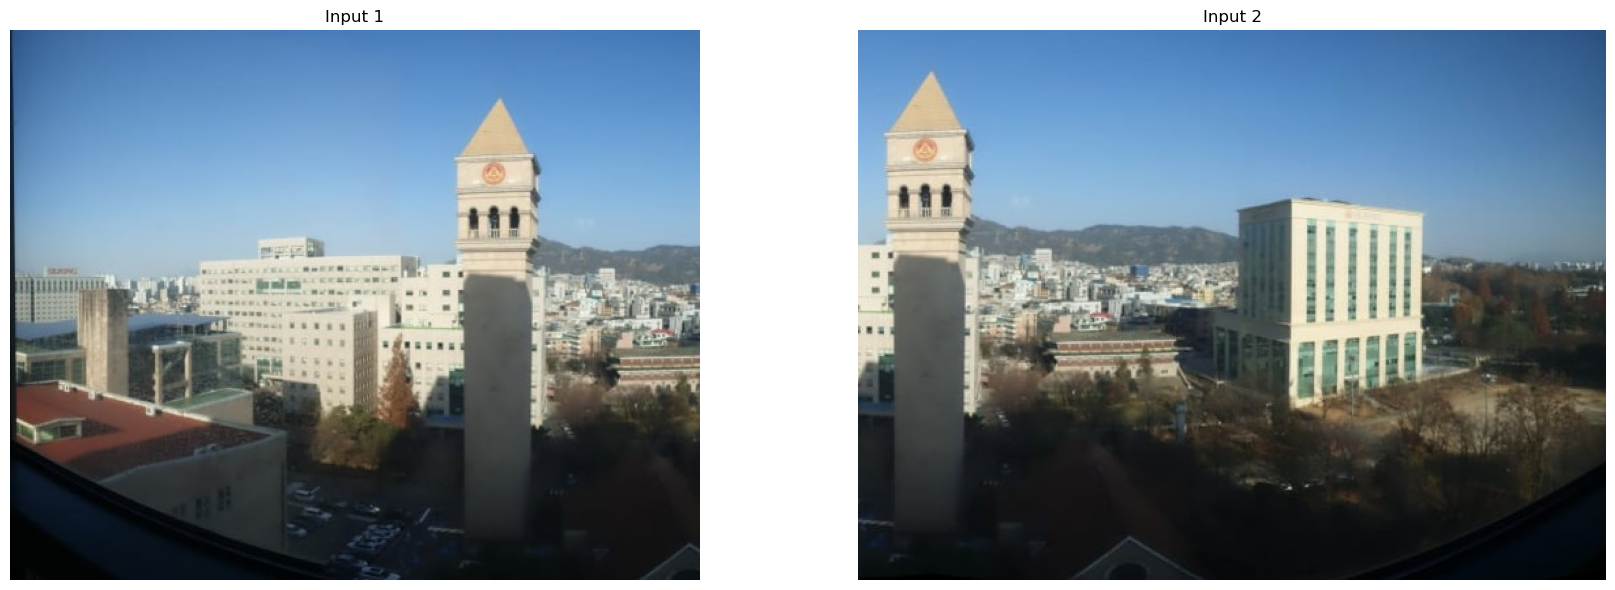


Showing feature matching between first two images...
Good matches between first two images: 809


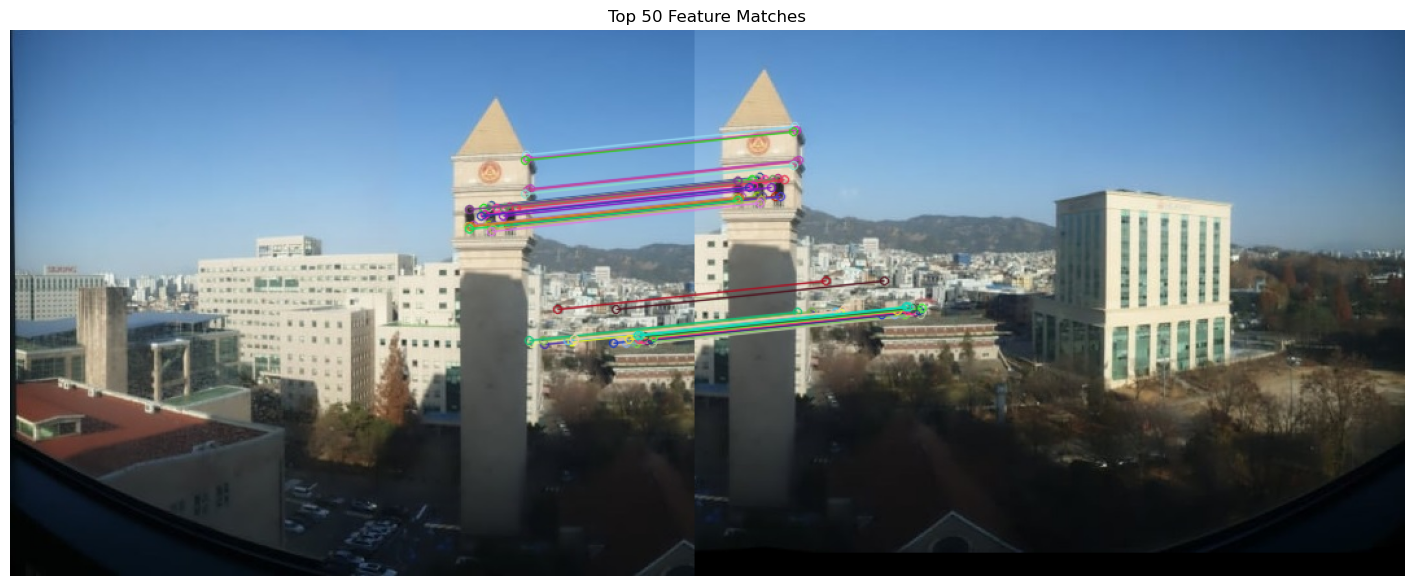


Running manual sequential stitching...

Stitching image 2 of 2...
Good matches found: 809


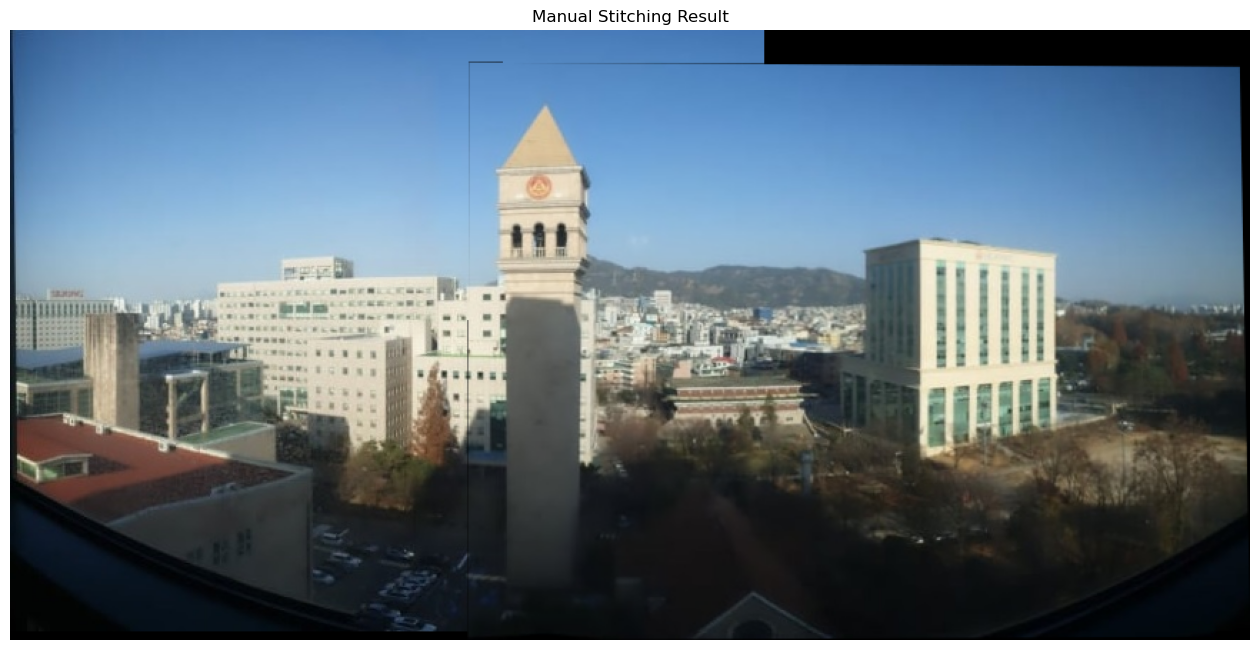

Saved: output_panorama\manual_panorama.jpg

Running OpenCV Stitcher (PANORAMA mode)...
PANORAMA mode stitching successful!


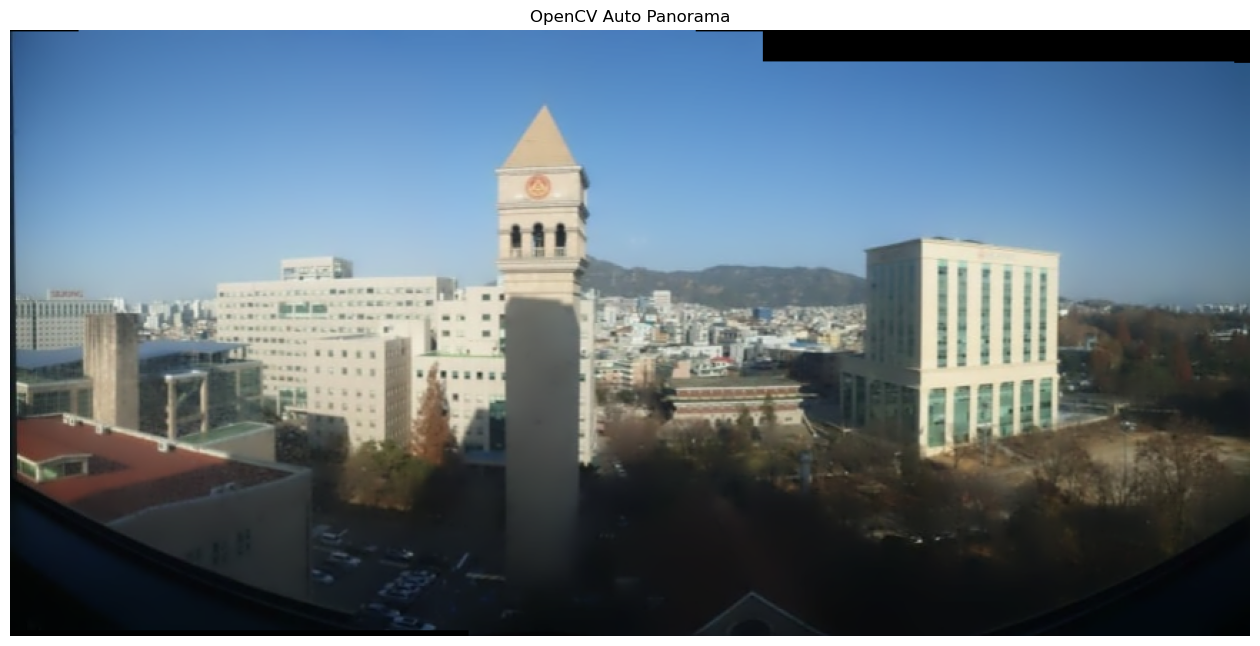

Saved: output_panorama\opencv_panorama.jpg

Running OpenCV Stitcher (SCANS mode)...
SCANS mode stitching successful!


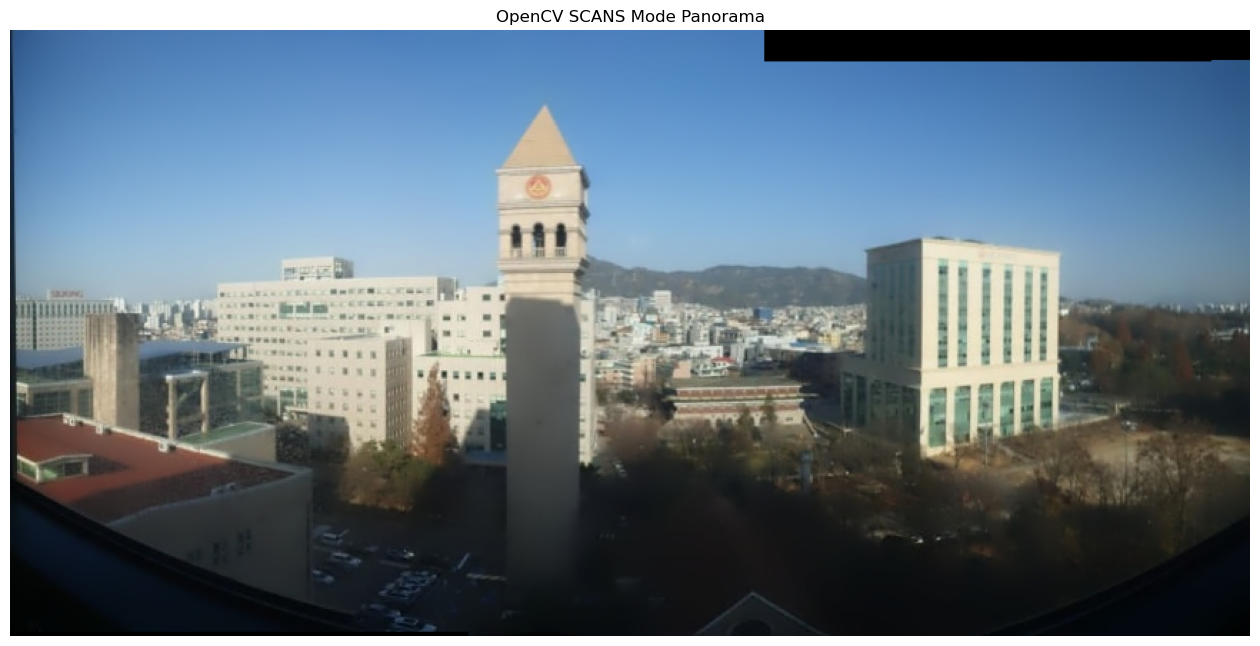

Saved: output_panorama\opencv_scans_panorama.jpg


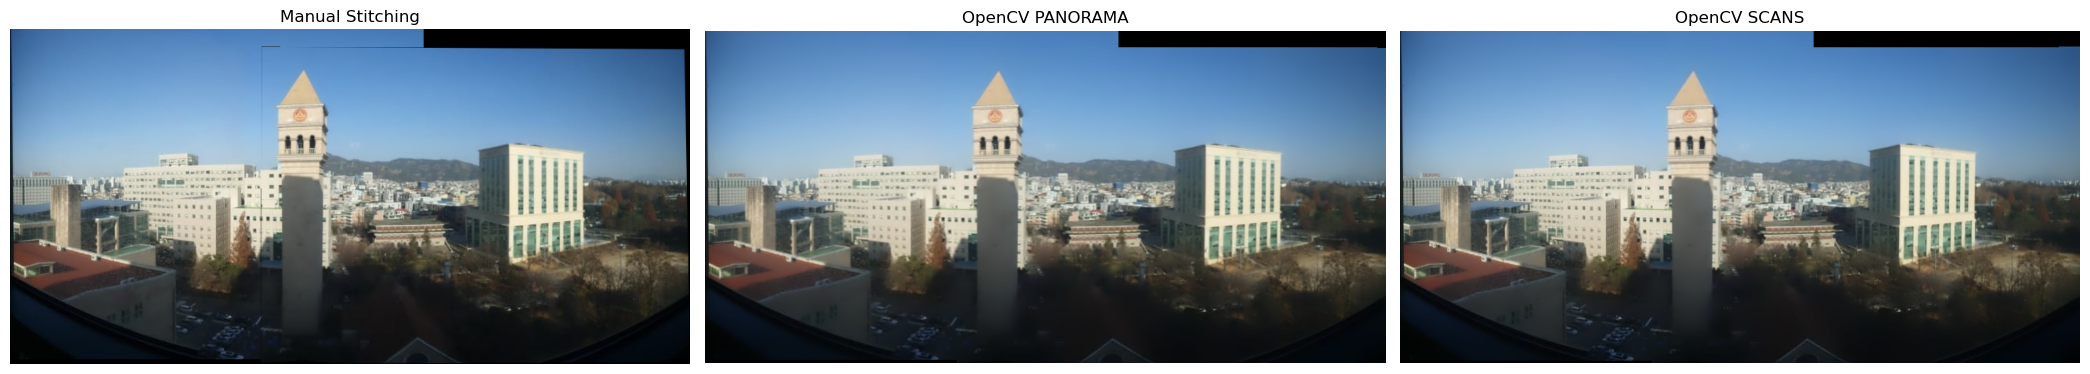


Best final output selected: OpenCV PANORAMA


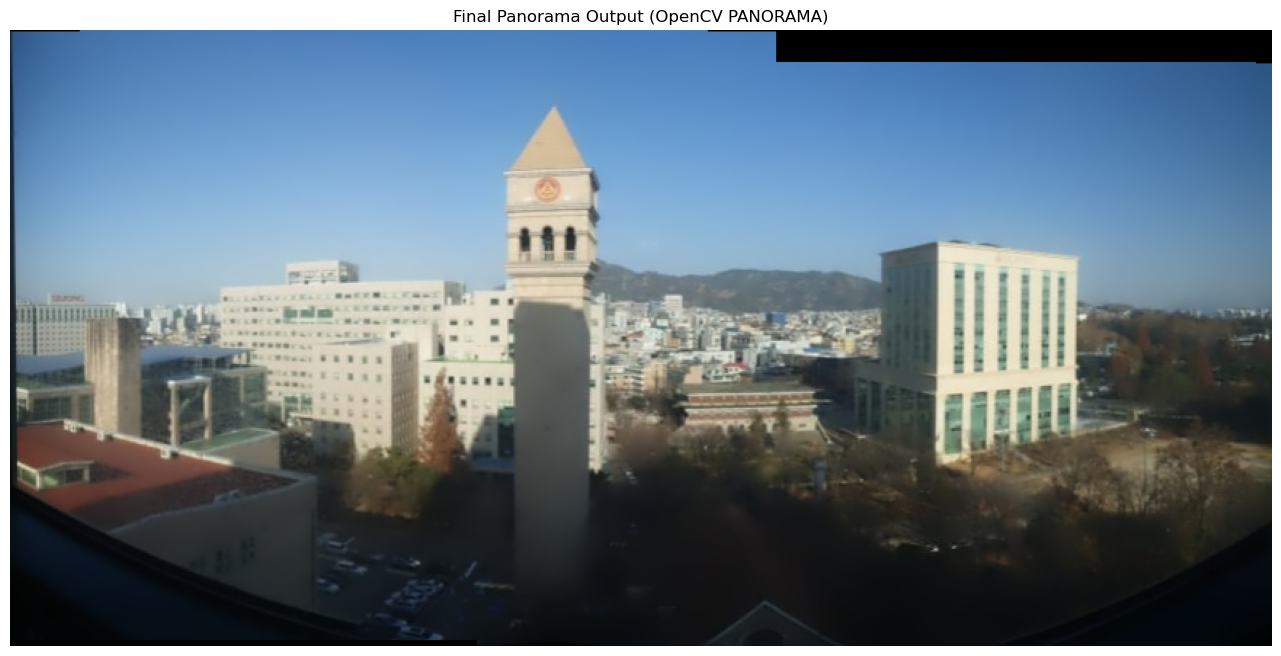

Saved: output_panorama\final_panorama_output.jpg

Lab completed successfully!


In [5]:
# ────────────────────────────────────────────────
# 0. Configuration & Helper Functions
# ────────────────────────────────────────────────

# Kaggle dataset image folder
IMAGE_FOLDER = os.path.join(path, "data")
IMAGE_EXTENSIONS = [".jpg", ".jpeg", ".png"]

# Output folder for results
OUTPUT_FOLDER = "output_panorama"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

def load_images(folder: str) -> List[np.ndarray]:
    """Load all valid images from folder"""
    if not os.path.exists(folder):
        raise FileNotFoundError(f"Folder not found: {folder}")
    
    images = []
    valid_files = []
    
    for file in sorted(os.listdir(folder)):
        full_path = os.path.join(folder, file)
        if os.path.isfile(full_path) and Path(file).suffix.lower() in IMAGE_EXTENSIONS:
            img = cv2.imread(full_path)
            if img is not None:
                images.append(img)
                valid_files.append(file)
                print(f"Loaded: {file} | shape: {img.shape}")
            else:
                print(f"Skipped unreadable file: {file}")
    
    print(f"\nTotal images loaded: {len(images)}")
    return images

def show_images(images: List[np.ndarray], titles: List[str] = None, figsize=(16, 6)):
    """Display multiple images side by side"""
    n = len(images)
    if n == 0:
        print("No images to display.")
        return
    
    plt.figure(figsize=figsize)
    for i, img in enumerate(images):
        plt.subplot(1, n, i + 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(titles[i] if titles and i < len(titles) else f"Image {i+1}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

def save_image(img: np.ndarray, filename: str):
    """Save image to output folder"""
    save_path = os.path.join(OUTPUT_FOLDER, filename)
    cv2.imwrite(save_path, img)
    print(f"Saved: {save_path}")

def crop_black_borders(img: np.ndarray) -> np.ndarray:
    """Remove black borders from stitched panorama"""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)

    coords = cv2.findNonZero(thresh)
    if coords is None:
        return img

    x, y, w, h = cv2.boundingRect(coords)
    cropped = img[y:y+h, x:x+w]
    return cropped

# ────────────────────────────────────────────────
# 1. Manual Stitching Pipeline
# ────────────────────────────────────────────────

def detect_and_match_features(img1: np.ndarray, img2: np.ndarray):
    """Detect ORB features and match between two images"""
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    orb = cv2.ORB_create(nfeatures=3000)

    kp1, des1 = orb.detectAndCompute(gray1, None)
    kp2, des2 = orb.detectAndCompute(gray2, None)

    if des1 is None or des2 is None:
        return kp1, des1, kp2, des2, []

    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
    matches = bf.knnMatch(des1, des2, k=2)

    good_matches = []
    for pair in matches:
        if len(pair) == 2:
            m, n = pair
            if m.distance < 0.75 * n.distance:
                good_matches.append(m)

    return kp1, des1, kp2, des2, good_matches

def draw_feature_matches(img1, kp1, img2, kp2, good_matches, max_matches=50):
    """Draw top feature matches"""
    match_vis = cv2.drawMatches(
        img1, kp1, img2, kp2,
        good_matches[:max_matches],
        None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )
    plt.figure(figsize=(18, 8))
    plt.imshow(cv2.cvtColor(match_vis, cv2.COLOR_BGR2RGB))
    plt.title(f"Top {min(len(good_matches), max_matches)} Feature Matches")
    plt.axis("off")
    plt.show()

def compute_homography(kp1, kp2, good_matches, min_matches=10):
    """Estimate homography using RANSAC"""
    if len(good_matches) < min_matches:
        return None, None

    src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

    H, mask = cv2.findHomography(dst_pts, src_pts, cv2.RANSAC, 5.0)
    return H, mask

def stitch_two_images(img1: np.ndarray, img2: np.ndarray, H: np.ndarray):
    """Warp img2 onto img1 canvas and blend overlap"""
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]

    corners_img2 = np.float32([[0, 0], [0, h2], [w2, h2], [w2, 0]]).reshape(-1, 1, 2)
    warped_corners_img2 = cv2.perspectiveTransform(corners_img2, H)

    corners_img1 = np.float32([[0, 0], [0, h1], [w1, h1], [w1, 0]]).reshape(-1, 1, 2)
    all_corners = np.concatenate((corners_img1, warped_corners_img2), axis=0)

    [xmin, ymin] = np.int32(all_corners.min(axis=0).ravel() - 0.5)
    [xmax, ymax] = np.int32(all_corners.max(axis=0).ravel() + 0.5)

    translation = np.array([
        [1, 0, -xmin],
        [0, 1, -ymin],
        [0, 0, 1]
    ], dtype=np.float32)

    output_width = xmax - xmin
    output_height = ymax - ymin

    warped_img2 = cv2.warpPerspective(img2, translation @ H, (output_width, output_height))
    result = warped_img2.copy()

    # place img1 on canvas
    x_offset = -xmin
    y_offset = -ymin

    roi = result[y_offset:y_offset+h1, x_offset:x_offset+w1]

    # simple overlap-aware blending
    img1_mask = np.any(img1 > 0, axis=2)
    roi_mask = np.any(roi > 0, axis=2)

    overlap = img1_mask & roi_mask
    only_img1 = img1_mask & ~roi_mask

    blended_roi = roi.copy()
    blended_roi[only_img1] = img1[only_img1]
    blended_roi[overlap] = ((roi[overlap].astype(np.float32) + img1[overlap].astype(np.float32)) / 2).astype(np.uint8)

    result[y_offset:y_offset+h1, x_offset:x_offset+w1] = blended_roi
    return result

def simple_stitch_all(images: List[np.ndarray]):
    """Sequentially stitch list of images"""
    panorama = images[0].copy()

    for i in range(1, len(images)):
        print(f"\nStitching image {i+1} of {len(images)}...")
        kp1, des1, kp2, des2, good = detect_and_match_features(panorama, images[i])

        print(f"Good matches found: {len(good)}")
        if len(good) < 10:
            print(f"Skipped image {i+1}: not enough matches")
            continue

        H, mask = compute_homography(kp1, kp2, good)
        if H is None:
            print(f"Skipped image {i+1}: homography failed")
            continue

        panorama = stitch_two_images(panorama, images[i], H)
        panorama = crop_black_borders(panorama)

    return panorama

# ────────────────────────────────────────────────
# 2. Load Images
# ────────────────────────────────────────────────

print("Image folder:", IMAGE_FOLDER)
print("Files inside folder:", os.listdir(IMAGE_FOLDER))

images = load_images(IMAGE_FOLDER)

if len(images) < 2:
    raise ValueError("Need at least 2 images to stitch")

show_images(images[:min(4, len(images))],
            titles=[f"Input {i+1}" for i in range(min(4, len(images)))],
            figsize=(18, 6))

# ────────────────────────────────────────────────
# 3. Show Feature Matching on First Two Images
# ────────────────────────────────────────────────

print("\nShowing feature matching between first two images...")
kp1, des1, kp2, des2, good = detect_and_match_features(images[0], images[1])
print("Good matches between first two images:", len(good))

if len(good) > 0:
    draw_feature_matches(images[0], kp1, images[1], kp2, good)

# ────────────────────────────────────────────────
# 4. Manual Sequential Stitching
# ────────────────────────────────────────────────

print("\nRunning manual sequential stitching...")
manual_panorama = simple_stitch_all(images)
manual_panorama = crop_black_borders(manual_panorama)

plt.figure(figsize=(16, 8))
plt.imshow(cv2.cvtColor(manual_panorama, cv2.COLOR_BGR2RGB))
plt.title("Manual Stitching Result")
plt.axis("off")
plt.show()

save_image(manual_panorama, "manual_panorama.jpg")

# ────────────────────────────────────────────────
# 5. OpenCV Built-in Stitcher (PANORAMA)
# ────────────────────────────────────────────────

print("\nRunning OpenCV Stitcher (PANORAMA mode)...")
stitcher = cv2.Stitcher_create(cv2.Stitcher_PANORAMA)
status, pano = stitcher.stitch(images)

pano_ok = False
if status == cv2.Stitcher_OK:
    pano_ok = True
    pano = crop_black_borders(pano)
    print("PANORAMA mode stitching successful!")

    plt.figure(figsize=(16, 8))
    plt.imshow(cv2.cvtColor(pano, cv2.COLOR_BGR2RGB))
    plt.title("OpenCV Auto Panorama")
    plt.axis("off")
    plt.show()

    save_image(pano, "opencv_panorama.jpg")
else:
    print("PANORAMA mode stitching failed. Status code:", status)

# ────────────────────────────────────────────────
# 6. OpenCV SCANS Mode
# ────────────────────────────────────────────────

print("\nRunning OpenCV Stitcher (SCANS mode)...")
stitcher_scans = cv2.Stitcher_create(cv2.Stitcher_SCANS)
status_scans, pano_scans = stitcher_scans.stitch(images)

scans_ok = False
if status_scans == cv2.Stitcher_OK:
    scans_ok = True
    pano_scans = crop_black_borders(pano_scans)
    print("SCANS mode stitching successful!")

    plt.figure(figsize=(16, 8))
    plt.imshow(cv2.cvtColor(pano_scans, cv2.COLOR_BGR2RGB))
    plt.title("OpenCV SCANS Mode Panorama")
    plt.axis("off")
    plt.show()

    save_image(pano_scans, "opencv_scans_panorama.jpg")
else:
    print("SCANS mode stitching failed. Status code:", status_scans)

# ────────────────────────────────────────────────
# 7. Compare Results
# ────────────────────────────────────────────────

results = [manual_panorama]
titles = ["Manual Stitching"]

if pano_ok:
    results.append(pano)
    titles.append("OpenCV PANORAMA")

if scans_ok:
    results.append(pano_scans)
    titles.append("OpenCV SCANS")

if len(results) > 1:
    plt.figure(figsize=(7 * len(results), 6))
    for i, img in enumerate(results):
        plt.subplot(1, len(results), i + 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(titles[i])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# ────────────────────────────────────────────────
# 8. Final Best Output
# ────────────────────────────────────────────────

final_output = None
final_name = ""

if pano_ok:
    final_output = pano
    final_name = "OpenCV PANORAMA"
elif scans_ok:
    final_output = pano_scans
    final_name = "OpenCV SCANS"
else:
    final_output = manual_panorama
    final_name = "Manual Stitching"

print(f"\nBest final output selected: {final_name}")

plt.figure(figsize=(18, 8))
plt.imshow(cv2.cvtColor(final_output, cv2.COLOR_BGR2RGB))
plt.title(f"Final Panorama Output ({final_name})")
plt.axis("off")
plt.show()

save_image(final_output, "final_panorama_output.jpg")

print("\nLab completed successfully!")